In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
kakao = pd.read_csv("preprocessed_reviews_kakaomap.csv", encoding='utf-8')
google = pd.read_csv("preprocessed_reviews_googlemap.csv", encoding='utf-8')
catchtable = pd.read_csv("preprocessed_reviews_catchtable.csv", encoding = 'utf-8')

In [ ]:
google.head()

,rating,content,date,weekday,vector
0,5,제주도를 몇번을 오고도 기다리는걸 힘들어해서 엄두도 안내고있다가 오후 4시쯤 방문하...,2025-07-22,1,"[-0.0025, -0.0023, 0.0008, -0.0014, -0.0020, -..."
1,3,6년만에 다시 방문한 연돈은 예전의 그 모습을 잃어버렸다.,2025-07-20,6,"[0.0055, 0.0003, 0.0009, -0.0012, -0.0028, -0...."
2,1,돈까스 장인은.. 개뿔\n\n김응서도 공범이다,2025-07-19,5,"[-0.0022, -0.0036, -0.0019, -0.0018, 0.0126, 0..."
3,2,등심까스는 맛있었지만 안심까스는 글쎄요 기름을 잔뜩먹어서 부드럽지만 너무 느끼했습니...,2025-07-19,5,"[-0.0011, 0.0000, -0.0034, 0.0002, 0.0004, -0...."
4,3,너무 오래 기다려시 힘드렀이오.\n맛은 다른곳과 별다르지 않음,2025-07-18,4,"[0.0027, 0.0055, -0.0070, 0.0020, 0.0000, -0.0..."


In [ ]:
catchtable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   rating   423 non-null    int64 
 1   content  423 non-null    object
 2   date     423 non-null    object
 3   weekday  423 non-null    int64 
 4   vector   423 non-null    object
dtypes: int64(2), object(3)
memory usage: 16.7+ KB


In [18]:
catchtable['rating'].describe()

count    526.000000
mean       4.875095
std        0.230543
min        4.000000
25%        4.700000
50%        5.000000
75%        5.000000
max        5.000000
Name: rating, dtype: float64

캐치테이블은 4-5 에만 있어서 앱에서 확인해본 결과 리뷰가 '베스트순'으로 정렬된 상태로 크롤링된것 같음.

(원래 4-5 사이로만 선택 가능한거면 표준화할까 했는데, 실제 리뷰는 1-5 사이라서 안함.)

In [6]:
kakao['date_datetime'] = pd.to_datetime(kakao['date'], errors = 'coerce')
google['date_datetime'] = pd.to_datetime(google['date'], errors = 'coerce')
catchtable['date_datetime'] = pd.to_datetime(catchtable['date'], errors = 'coerce')

In [7]:
kakao['year'] = kakao['date_datetime'].dt.year
google['year'] = google['date_datetime'].dt.year
catchtable['year'] = catchtable['date_datetime'].dt.year

In [28]:
kakao['month'] = kakao['date_datetime'].dt.to_period("M")
google['month'] = google['date_datetime'].dt.to_period("M")
catchtable['month'] = catchtable['date_datetime'].dt.to_period("M")

In [29]:
kakao.head()

,rating,content,date,weekday,vector,date_datetime,year,month
0,5,제주도를 몇번을 오고도 기다리는걸 힘들어해서 엄두도 안내고있다가 오후 4시쯤 방문하...,2025-07-22,1,"[-0.0025, -0.0023, 0.0008, -0.0014, -0.0020, -...",2025-07-22,2025,2025-07
1,3,6년만에 다시 방문한 연돈은 예전의 그 모습을 잃어버렸다.,2025-07-20,6,"[0.0055, 0.0003, 0.0009, -0.0012, -0.0028, -0....",2025-07-20,2025,2025-07
2,1,돈까스 장인은.. 개뿔\n\n김응서도 공범이다,2025-07-19,5,"[-0.0022, -0.0036, -0.0019, -0.0018, 0.0126, 0...",2025-07-19,2025,2025-07
3,2,등심까스는 맛있었지만 안심까스는 글쎄요 기름을 잔뜩먹어서 부드럽지만 너무 느끼했습니...,2025-07-19,5,"[-0.0011, 0.0000, -0.0034, 0.0002, 0.0004, -0....",2025-07-19,2025,2025-07
4,3,너무 오래 기다려시 힘드렀이오.\n맛은 다른곳과 별다르지 않음,2025-07-18,4,"[0.0027, 0.0055, -0.0070, 0.0020, 0.0000, -0.0...",2025-07-18,2025,2025-07


1. 각 사이트별 특정 키워드 언급 빈도 비교

'동네'
- '동네 식당', '동네 식당'과 비교한 경우를 알아보기 위해

In [9]:
kakao_dongne = 0
for i in range(len(kakao)):
    if '동네' in kakao['content'][i]:
        kakao_dongne += 1
    else:
        continue

google_dongne = 0
for i in range(len(google)):
    if '동네' in google['content'][i]:
        google_dongne += 1
    else:
        continue

catchtable_dongne = 0
for i in range(len(catchtable)):
    if '동네' in catchtable['content'][i]:
        catchtable_dongne += 1
    else:
        continue    

print(f"카카오맵에서는 {len(kakao)}개 리뷰 중 '동네'가 {kakao_dongne}번 언급됨", )
print(f"구글에서는 {len(google)}개 리뷰 중 '동네'가 {google_dongne}번 언급됨", )
print(f"캐치테이블에서는 {len(catchtable)}개 리뷰 중 '동네'가 {catchtable_dongne}번 언급됨", )

카카오맵에서는 423개 리뷰 중 '동네'가 29번 언급됨
구글에서는 462개 리뷰 중 '동네'가 11번 언급됨
캐치테이블에서는 526개 리뷰 중 '동네'가 26번 언급됨


충분한 개수가 되지 않는다고 파악.

'백종원'
- 최근 논란이 되며 언급량이 많아지고 있음. 

In [10]:
kakao_paik = 0
for i in range(len(kakao)):
    if '백종원' in kakao['content'][i]:
        kakao_paik += 1
    else:
        continue

google_paik = 0
for i in range(len(google)):
    if '백종원' in google['content'][i]:
        google_paik += 1
    else:
        continue

catchtable_paik = 0
for i in range(len(catchtable)):
    if '백종원' in catchtable['content'][i]:
        catchtable_paik += 1
    else:
        continue    

print(f"카카오맵에서는 {len(kakao)}개 리뷰 중 '백종원'가 {kakao_paik}번 언급됨", )
print(f"구글에서는 {len(google)}개 리뷰 중 '백종원'가 {google_paik}번 언급됨", )
print(f"캐치테이블에서는 {len(catchtable)}개 리뷰 중 '백종원'가 {catchtable_paik}번 언급됨", )

카카오맵에서는 423개 리뷰 중 '백종원'가 19번 언급됨
구글에서는 462개 리뷰 중 '백종원'가 11번 언급됨
캐치테이블에서는 526개 리뷰 중 '백종원'가 0번 언급됨


2. 요일에 따른 평균 별점 비교

In [ ]:
kakao_days = {'월요일':0, '화요일':0, '수요일':0, '목요일':0, '금요일':0, '토요일':0, '일요일':0}

for i in range(6):
    if i == 0:
        kakao_days['월요일'] = kakao[kakao['weekday']==i]['rating'].mean()
    elif i == 1:
        kakao_days['화요일'] = kakao[kakao['weekday']==i]['rating'].mean()
    elif i==2:
        kakao_days['수요일'] = kakao[kakao['weekday']==i]['rating'].mean()
    elif i==3:
        kakao_days['목요일'] = kakao[kakao['weekday']==i]['rating'].mean()
    elif i==4:
        kakao_days['금요일'] = kakao[kakao['weekday']==i]['rating'].mean()
    elif i==5:
        kakao_days['토요일'] = kakao[kakao['weekday']==i]['rating'].mean()
    elif i==6:
        kakao_days['일요일'] = kakao[kakao['weekday']==i]['rating'].mean()

print(kakao_days)

{'월요일': 3.730769230769231, '화요일': 3.390625, '수요일': 3.1343283582089554, '목요일': 3.737704918032787, '금요일': 3.3404255319148937, '토요일': 3.5625, '일요일': 0}


In [17]:
catchtable_days = {'월요일':0, '화요일':0, '수요일':0, '목요일':0, '금요일':0, '토요일':0, '일요일':0}

for i in range(6):
    if i == 0:
        catchtable_days['월요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()
    elif i == 1:
        catchtable_days['화요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()
    elif i==2:
        catchtable_days['수요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()
    elif i==3:
        catchtable_days['목요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()
    elif i==4:
        catchtable_days['금요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()
    elif i==5:
        catchtable_days['토요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()
    elif i==6:
        catchtable_days['일요일'] = catchtable[catchtable['weekday']==i]['rating'].mean()

print(catchtable_days)

{'월요일': 5.0, '화요일': 4.897872340425531, '수요일': 4.708333333333333, '목요일': 4.770212765957447, '금요일': 5.0, '토요일': 4.85531914893617, '일요일': 0}


In [16]:
google_days = {'월요일':0, '화요일':0, '수요일':0, '목요일':0, '금요일':0, '토요일':0, '일요일':0}

for i in range(6):
    if i == 0:
        google_days['월요일'] = google[google['weekday']==i]['rating'].mean()
    elif i == 1:
        google_days['화요일'] = google[google['weekday']==i]['rating'].mean()
    elif i==2:
        google_days['수요일'] = google[google['weekday']==i]['rating'].mean()
    elif i==3:
        google_days['목요일'] = google[google['weekday']==i]['rating'].mean()
    elif i==4:
        google_days['금요일'] = google[google['weekday']==i]['rating'].mean()
    elif i==5:
        google_days['토요일'] = google[google['weekday']==i]['rating'].mean()
    elif i==6:
        google_days['일요일'] = google[google['weekday']==i]['rating'].mean()

print(google_days)

{'월요일': 4.1020408163265305, '화요일': 3.55, '수요일': 4.5, '목요일': 4.228070175438597, '금요일': 4.1558441558441555, '토요일': 4.27027027027027, '일요일': 0}


세 딕셔너리에 있는 숫자들을 막대 그래프로 투명도 다르게 / 선 그래프로 나타내면 좋을 것 같아요!

3. 시간(월 단위)에 따른 평균 별점 추이

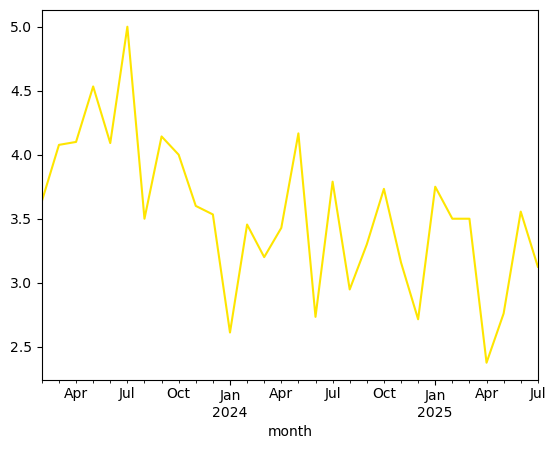

In [34]:
plt.figure()
kakao_monthly_avg = kakao.groupby('month')['rating'].mean().sort_index()

kakao_monthly_avg.plot(color = '#FEE500')

plt.show()

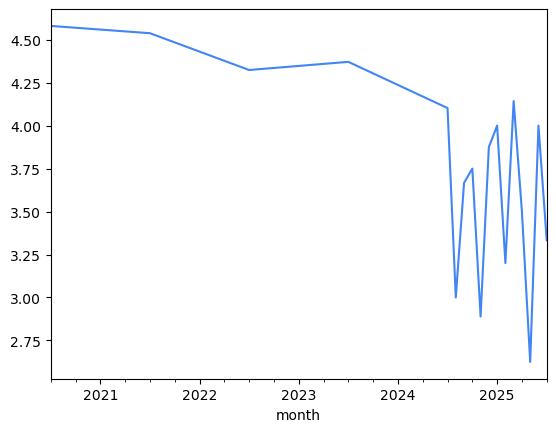

In [38]:
plt.figure()
google_monthly_avg = google.groupby('month')['rating'].mean().sort_index()

google_monthly_avg.plot(color = '#4285F4')

plt.show()

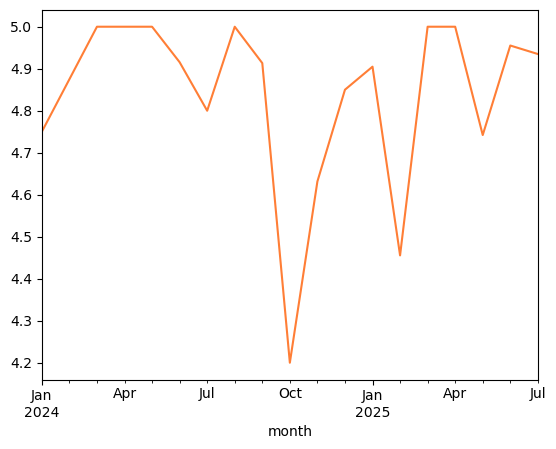

In [39]:
plt.figure()
catchtable_monthly_avg = catchtable.groupby('month')['rating'].mean().sort_index()

catchtable_monthly_avg.plot(color = '#FF7E36')

plt.show()

4. 사이트별 긍정 리뷰, 부정 리뷰 개수 비교 (작업중)

In [ ]:
kakao